# <a href="https://girafe.ai/" target="_blank" rel="noopener noreferrer"><img src="https://raw.githubusercontent.com/girafe-ai/ml-course/7096a5df4cada5ee651be1e3215c2f7fb8a7e0bf/logo_margin.svg" alt="girafe-ai logo" width="150px" align="left"></a> [ml-basic course](https://github.com/girafe-ai/ml-course) <a class="tocSkip">

# Lab assignment 01
## Data preprocessing, model training and evaluation

This lab assignment consists of several parts.

In this part you are supposed to work with tabular data: make some transformations, train some models, estimate the quality of the models and explain your results.

Several comments:
* Don't hesitate to ask questions in a chat, it's a good practice.
* No private/public sharing, please. The copied assignments will be graded with 0 points.
* Blocks of this lab will be graded separately.

## 1. Reading the data
Today we work with the [dataset](https://archive.ics.uci.edu/ml/datasets/Statlog+%28Vehicle+Silhouettes%29), describing different cars for multiclass ($k=4$) classification problem. The data is available below.

In [2]:
!pip install ucimlrepo

In [3]:
import ucimlrepo as uci
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

In [4]:
dataset = uci.fetch_ucirepo(id=149)

print(dataset.metadata.name, '\n')
print(dataset.metadata.abstract, '\n')
print(dataset.metadata.additional_info.summary, '\n')

Statlog (Vehicle Silhouettes) 

3D objects within a 2D image by application of an ensemble of shape feature extractors to the 2D silhouettes of the objects. 

The purpose is to classify a given silhouette as one of four types of vehicle, using  a set of features extracted from the silhouette. The vehicle may be viewed from one of many different angles.  

HISTORY:

This data was originally gathered at the TI in 1986-87 by JP Siebert. It was partially financed by Barr and Stroud Ltd. The original purpose was to find a method of distinguishing 3D objects within a 2D image by application of an ensemble of shape feature extractors to the 2D silhouettes of the objects. Measures of shape features extracted from example silhouettes of objects to be discriminated were used to generate a classification rule tree by means of computer induction.

This object recognition strategy was successfully used to discriminate between silhouettes of model cars, vans and buses viewed from constrained elevati

In [5]:
data = dataset.data.features
target = dataset.data.targets

print(data.shape, target.shape)

(846, 18) (846, 1)


### 1.1 Data integrity

Check if data is valid. If it is not, remove invalid parts.


In [6]:
# your code here

# удаление строк с NaN
print("NaN values per column before:", data.isna().sum().tolist())
data = data.dropna()
target = target.loc[data.index]

# удаление строк с бесконечностями
inf_rows = np.isinf(data).any(axis=1)
print("Rows with inf before:", inf_rows.sum())

data = data[~inf_rows]
target = target.loc[data.index]

# удаление дубликатов
dup_rows = data.duplicated().sum()
print("Duplicated rows before:", dup_rows)

data = data.drop_duplicates()
target = target.loc[data.index]

# размеры после чистки данных
print("Final shapes:", data.shape, target.shape)


NaN values per column before: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Rows with inf before: 0
Duplicated rows before: 0
Final shapes: (845, 18) (845, 1)


### 1.2 Train and test sets

Split data into 2 groups using `sklearn`'s infrastructure.

Which size of test set to choose?

In [7]:
# your code here

from sklearn.model_selection import train_test_split

# 20% оставим для теста
X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=0.2, random_state=42, stratify=target)

In [8]:
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(676, 18) (676, 1) (169, 18) (169, 1)


To get some insights about the dataset, `pandas` might be used. The `train` part is transformed to `pd.DataFrame` below.

In [9]:
X_train_pd = pd.DataFrame(X_train)

# First 15 rows of our dataset.
X_train_pd.head(15)

,COMPACTNESS,CIRCULARITY,DISTANCE CIRCULARITY,RADIUS RATIO,PR.AXIS ASPECT RATIO,MAX.LENGTH ASPECT RATIO,SCATTER RATIO,ELONGATEDNESS,PR.AXIS RECTANGULARITY,MAX.LENGTH RECTANGULARITY,SCALED VARIANCE ALONG MAJOR AXIS,SCALED VARIANCE ALONG MINOR AXIS,SCALED RADIUS OF GYRATION,SKEWNESS ABOUT MAJOR AXIS,SKEWNESS ABOUT MINOR AXIS,KURTOSIS ABOUT MINOR AXIS,KURTOSIS ABOUT MAJOR AXIS,HOLLOWS RATIO
200,93.0,47,85,163,66,11,156,44,20,158,172,355,178,74,7,15,183,195
396,108.0,57,106,177,51,5,256,26,28,170,285,966,261,87,11,2,182,181
309,109.0,48,107,215,62,10,205,32,23,158,222,624,168,65,9,32,195,206
86,89.0,41,84,141,58,9,149,45,19,145,172,330,162,72,4,18,188,200
635,97.0,41,62,133,56,7,130,52,18,143,158,247,157,78,5,7,184,186
246,95.0,36,73,191,73,6,156,41,19,126,184,374,124,71,2,19,199,204
782,87.0,44,98,211,70,10,189,35,22,141,214,535,178,71,2,21,187,194
539,109.0,55,96,191,57,6,241,28,26,170,267,857,242,85,8,9,184,184
698,83.0,42,71,152,64,7,149,45,19,142,172,331,158,74,2,2,184,190
794,87.0,41,76,165,67,7,148,45,19,140,171,327,152,72,7,13,188,195


Methods `describe` and `info` deliver some useful information.

In [10]:
X_train_pd.describe()

,COMPACTNESS,CIRCULARITY,DISTANCE CIRCULARITY,RADIUS RATIO,PR.AXIS ASPECT RATIO,MAX.LENGTH ASPECT RATIO,SCATTER RATIO,ELONGATEDNESS,PR.AXIS RECTANGULARITY,MAX.LENGTH RECTANGULARITY,SCALED VARIANCE ALONG MAJOR AXIS,SCALED VARIANCE ALONG MINOR AXIS,SCALED RADIUS OF GYRATION,SKEWNESS ABOUT MAJOR AXIS,SKEWNESS ABOUT MINOR AXIS,KURTOSIS ABOUT MINOR AXIS,KURTOSIS ABOUT MAJOR AXIS,HOLLOWS RATIO
count,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000
mean,93.353550,44.788462,81.789941,168.440828,61.741124,8.693787,168.115385,41.106509,20.526627,147.902367,188.020710,435.831361,174.437870,72.576923,6.322485,12.321006,188.809172,195.534024
std,8.214937,6.119156,15.678160,33.935814,8.345653,5.024623,32.876717,7.760520,2.568908,14.480411,30.910904,174.266015,32.083742,7.707140,4.872857,8.982893,6.168064,7.425304
min,73.000000,33.000000,40.000000,104.000000,47.000000,3.000000,112.000000,26.000000,17.000000,118.000000,130.000000,184.000000,112.000000,59.000000,0.000000,0.000000,176.000000,181.000000
25%,87.000000,40.000000,70.000000,140.000000,57.000000,7.000000,146.000000,33.000000,19.000000,137.000000,167.000000,317.000000,150.000000,68.000000,2.000000,5.000000,184.000000,190.750000
50%,92.000000,44.000000,79.000000,166.000000,61.000000,8.000000,156.000000,43.000000,19.000000,146.000000,177.500000,360.500000,173.000000,72.000000,6.000000,11.000000,188.000000,197.000000
75%,99.000000,49.000000,96.500000,194.000000,65.000000,10.000000,197.000000,46.000000,23.000000,159.000000,217.000000,583.250000,198.000000,76.000000,9.000000,18.000000,193.000000,201.000000
max,119.000000,59.000000,112.000000,333.000000,138.000000,55.000000,265.000000,61.000000,29.000000,186.000000,320.000000,1018.000000,268.000000,135.000000,22.000000,41.000000,206.000000,211.000000


In [11]:
X_train_pd.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 676 entries, 200 to 656
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   COMPACTNESS                       676 non-null    float64
 1   CIRCULARITY                       676 non-null    int64  
 2   DISTANCE CIRCULARITY              676 non-null    int64  
 3   RADIUS RATIO                      676 non-null    int64  
 4   PR.AXIS ASPECT RATIO              676 non-null    int64  
 5   MAX.LENGTH ASPECT RATIO           676 non-null    int64  
 6   SCATTER RATIO                     676 non-null    int64  
 7   ELONGATEDNESS                     676 non-null    int64  
 8   PR.AXIS RECTANGULARITY            676 non-null    int64  
 9   MAX.LENGTH RECTANGULARITY         676 non-null    int64  
 10  SCALED VARIANCE ALONG MAJOR AXIS  676 non-null    int64  
 11  SCALED VARIANCE ALONG MINOR AXIS  676 non-null    int64  
 12  SCALED

## 2. Machine Learning pipeline
Here you are supposed to perform the desired transformations. Please, explain your results briefly after each task.

### 2.0. Data preprocessing

Apply transformations to the dataset (if necessary).

Briefly explain the transformations

In [12]:
### YOUR CODE HERE

from sklearn.preprocessing import StandardScaler

# создание scaler
scaler = StandardScaler()

# обучение на тренировочных данных и трансформируем
X_train_scaled = scaler.fit_transform(X_train_pd)
X_test_pd = pd.DataFrame(X_test)
# применяем к тестовым данным
X_test_scaled = scaler.transform(X_test_pd)

print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)

Train shape: (676, 18)
Test shape: (169, 18)


### 2.1. Basic logistic regression

* Find optimal hyperparameters for logistic regression with cross-validation on the `train` data (small grid/random search is enough, no need to find the *best* parameters).

* Estimate the model quality with `f1` and `accuracy` scores.
* Plot a ROC-curve for the trained model. For the multiclass case you might use `scikitplot` library (e.g. `scikitplot.metrics.plot_roc(test_labels, predicted_proba)`).

*Note: please, use the following hyperparameters for logistic regression:\
`multi_class='multinomial'`, `solver='saga'` `tol=1e-3` and ` max_iter=500`.*

c:\Users\Dell\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\Dell\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\Dell\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\Dell\AppData\Local\Programs\Python\Pytho

Лучшие параметры: {'C': 10, 'penalty': 'l1'}
Accuracy: 0.8521
F1 Macro: 0.8497
F1 Micro: 0.8521


<Figure size 1000x800 with 0 Axes>

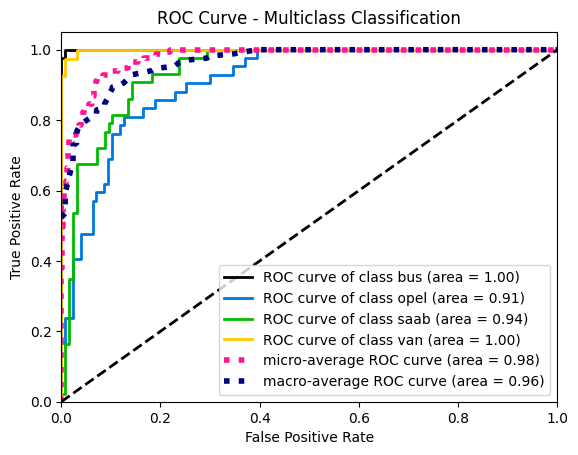

In [13]:
### YOUR CODE HERE

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, accuracy_score
import scikitplot as skplt
import matplotlib.pyplot as plt

# Создание модели логистической регрессии с указанными параметрами
lr_model = LogisticRegression(
    multi_class='multinomial',
    solver='saga',
    tol=1e-3,
    max_iter=500,
    random_state=42
)

# Поиск по сетке параметров
param_grid = {
    'C': [0.1, 1, 10],
    'penalty': ['l1', 'l2', 'elasticnet']
}

# Поиск лучших параметров с кросс-валидацией
grid_search = GridSearchCV(
    lr_model,
    param_grid,
    cv=3,
    scoring='f1_macro'
)

# Обучение модели
grid_search.fit(X_train_scaled, y_train.values.ravel())

# Лучшая модель
best_model = grid_search.best_estimator_

# Предсказания на тестовых данных
y_pred = best_model.predict(X_test_scaled)
y_pred_proba = best_model.predict_proba(X_test_scaled)

# Оценка качества модели
accuracy1 = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')
f1_micro = f1_score(y_test, y_pred, average='micro')

print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Accuracy: {accuracy1:.4f}")
print(f"F1 Macro: {f1_macro:.4f}")
print(f"F1 Micro: {f1_micro:.4f}")

# ROC-кривая
plt.figure(figsize=(10, 8))
skplt.metrics.plot_roc(y_test, y_pred_proba)
plt.title('ROC Curve - Multiclass Classification')
plt.show()

In [14]:
# You might use this command to install scikit-plot.
# Warning, if you a running locally, don't call pip from within jupyter, call it from terminal in the corresponding
# virtual environment instead

# ! pip install scikit-plot

### 2.2. PCA: explained variance plot

Apply the PCA to the train part of the data.

Build the explaided variance plot.

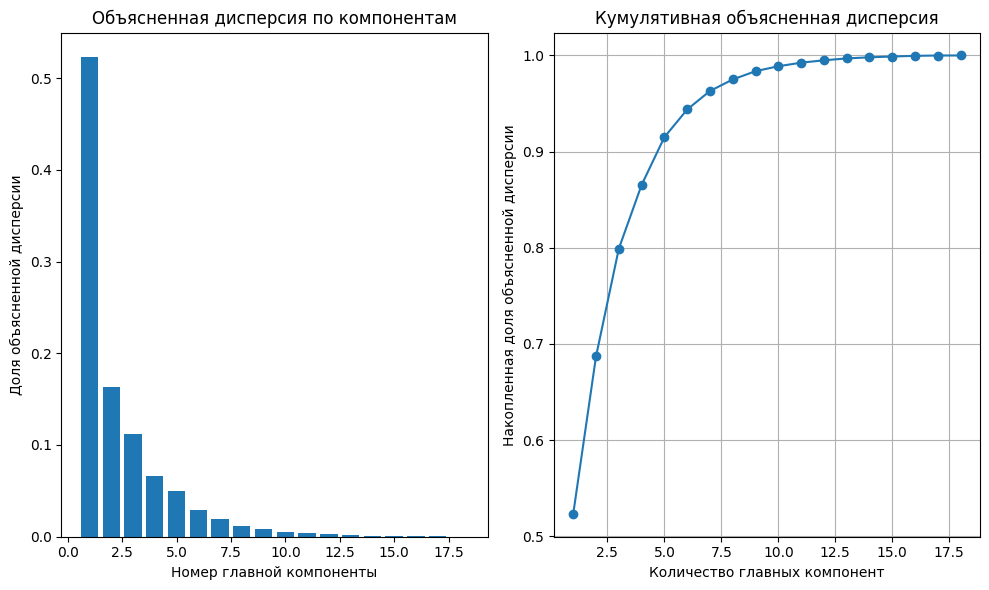

Объясненная дисперсия по компонентам:
Компонента 1: 0.5234 (52.34%)
Компонента 2: 0.1637 (16.37%)
Компонента 3: 0.1120 (11.20%)
Компонента 4: 0.0663 (6.63%)
Компонента 5: 0.0496 (4.96%)
Компонента 6: 0.0288 (2.88%)
Компонента 7: 0.0193 (1.93%)
Компонента 8: 0.0120 (1.20%)
Компонента 9: 0.0086 (0.86%)
Компонента 10: 0.0051 (0.51%)
Компонента 11: 0.0037 (0.37%)
Компонента 12: 0.0025 (0.25%)
Компонента 13: 0.0019 (0.19%)
Компонента 14: 0.0012 (0.12%)
Компонента 15: 0.0008 (0.08%)
Компонента 16: 0.0007 (0.07%)
Компонента 17: 0.0004 (0.04%)
Компонента 18: 0.0000 (0.00%)

Суммарная дисперсия всех компонент: 1.0000
Компонент для 95% дисперсии: 7
Дисперсия с 7 компонентами: 0.9631


In [15]:
### YOUR CODE HERE

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Применение PCA к тренировочным данным
pca = PCA()
pca.fit(X_train_scaled)

# построение графика объясненной дисперсии
plt.figure(figsize=(10, 6))

# Объясненная дисперсия для каждого компонента
plt.subplot(1, 2, 1)
plt.bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_)
plt.xlabel('Номер главной компоненты')
plt.ylabel('Доля объясненной дисперсии')
plt.title('Объясненная дисперсия по компонентам')

# Кумулятивная объясненная дисперсия
plt.subplot(1, 2, 2)
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), 
         np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Количество главных компонент')
plt.ylabel('Накопленная доля объясненной дисперсии')
plt.title('Кумулятивная объясненная дисперсия')
plt.grid(True)

plt.tight_layout()
plt.show()

# Информация о дисперсии
print("Объясненная дисперсия по компонентам:")
for i, variance in enumerate(pca.explained_variance_ratio_):
    print(f"Компонента {i+1}: {variance:.4f} ({variance*100:.2f}%)")

print(f"\nСуммарная дисперсия всех компонент: {sum(pca.explained_variance_ratio_):.4f}")

# Количество компонент нужное для объяснения 95% дисперсии
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Компонент для 95% дисперсии: {n_components_95}")
print(f"Дисперсия с {n_components_95} компонентами: {cumulative_variance[n_components_95-1]:.4f}")

### 2.3. PCA trasformation

Select the appropriate number of components.

Briefly explain your choice. Should you normalize the data?

*Use `fit` and `transform` methods to transform the `train`, `val` and `test` parts.*

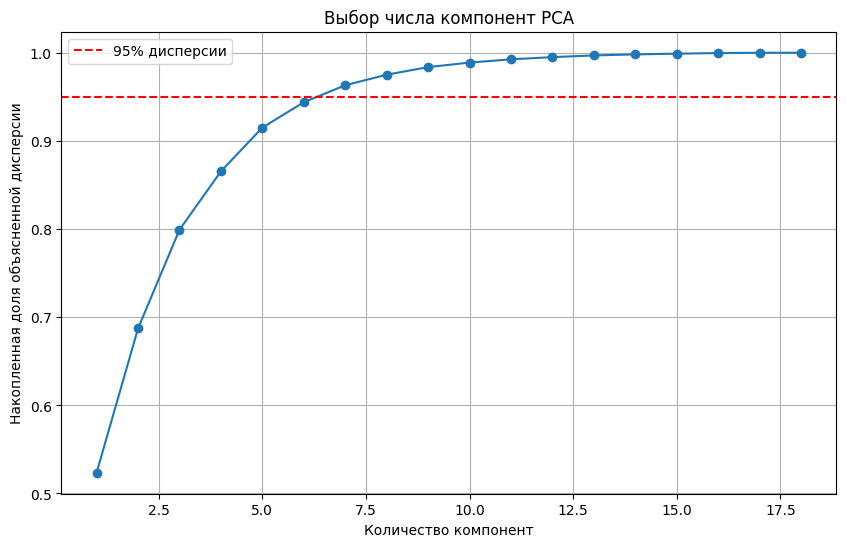

Компонент для 95% дисперсии: 7
Исходная размерность: 18
Размерность после PCA: 7


In [16]:
### YOUR CODE HERE

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# Делаем нормализацию данных для PCA
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Применение PCA
pca = PCA()
X_train_pca = pca.fit_transform(X_train_scaled)

# Построение графика объясненной дисперсии
plt.figure(figsize=(10, 6))

# Кумулятивная объясненная дисперсия
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% дисперсии')
plt.xlabel('Количество компонент')
plt.ylabel('Накопленная доля объясненной дисперсии')
plt.title('Выбор числа компонент PCA')
plt.legend()
plt.grid(True)
plt.show()

# Выбор числа компонент для 95% дисперсии
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Компонент для 95% дисперсии: {n_components_95}")

# Применение PCA с выбранным числом компонент
pca_final = PCA(n_components=n_components_95)
X_train_pca_final = pca_final.fit_transform(X_train_scaled)
X_test_pca_final = pca_final.transform(X_test_scaled)

print(f"Исходная размерность: {X_train.shape[1]}")
print(f"Размерность после PCA: {X_train_pca_final.shape[1]}")

Note: From this point `sklearn` [Pipeline](https://scikit-learn.org/stable/modules/compose.html) might be useful to perform transformations on the data. Refer to the [docs](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html) for more information.

### 2.4. Logistic regression on PCA-preprocessed data

* Find optimal hyperparameters for logistic regression with cross-validation on the transformed by PCA `train` data.
* Estimate the model quality with `f1` and `accuracy` scores.
* Plot a ROC-curve for the trained model. For the multiclass case you might use `scikitplot` library (e.g. `scikitplot.metrics.plot_roc(test_labels, predicted_proba)`).

*Note: please, use the following hyperparameters for logistic regression:\
`multi_class='multinomial'`, `solver='saga'` and `tol=1e-3`*

Размерность данных после PCA:
Тренировочные: (676, 7)
Тестовые: (169, 7)
Обучение логистической регрессии на PCA данных


c:\Users\Dell\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\Dell\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\Dell\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\Dell\AppData\Local\Programs\Python\Pytho


 Результаты на PCA данных
Лучшие параметры: {'C': 1, 'penalty': 'l2'}
Accuracy: 0.6272
F1 Macro: 0.6216
F1 Micro: 0.6272

 Сравнение с исходными данными
PCA данные (7 компонент): Accuracy = 0.6272
Исходные данные (18 признаков): Accuracy = 0.8521


<Figure size 1000x800 with 0 Axes>

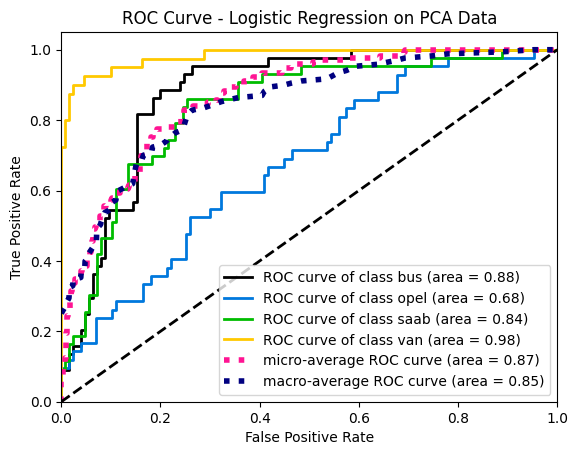

In [17]:
### YOUR CODE HERE

from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, accuracy_score
import scikitplot as skplt
import matplotlib.pyplot as plt
import numpy as np

# Применяем PCA с 7 компонентами
pca = PCA(n_components=n_components_95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Размерность данных после PCA:")
print(f"Тренировочные: {X_train_pca.shape}")
print(f"Тестовые: {X_test_pca.shape}")

# Создание модели логистической регрессии с указанными параметрами
lr_model = LogisticRegression(
    multi_class='multinomial',
    solver='saga',
    tol=1e-3,
    max_iter=500,
    random_state=42
)

#Поиск оптимальных гиперпараметров
param_grid = {
    'C': [0.1, 1, 10],
    'penalty': ['l1', 'l2', 'elasticnet']
}

#Кросс-валидация для поиска лучших параметров
grid_search = GridSearchCV(
    lr_model,
    param_grid,
    cv=3,
    scoring='f1_macro'
)

print("Обучение логистической регрессии на PCA данных")
grid_search.fit(X_train_pca, y_train.values.ravel())

# Лучшая модель
best_model = grid_search.best_estimator_

# Предсказания
y_pred_pca = best_model.predict(X_test_pca)
y_pred_proba_pca = best_model.predict_proba(X_test_pca)

# Оценка качества
accuracy_pca = accuracy_score(y_test, y_pred_pca)
f1_macro_pca = f1_score(y_test, y_pred_pca, average='macro')
f1_micro_pca = f1_score(y_test, y_pred_pca, average='micro')

print(f"\n Результаты на PCA данных")
print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Accuracy: {accuracy_pca:.4f}")
print(f"F1 Macro: {f1_macro_pca:.4f}")
print(f"F1 Micro: {f1_micro_pca:.4f}")

# Сравнение с исходными результатами 
print(f"\n Сравнение с исходными данными")
print(f"PCA данные ({n_components_95} компонент): Accuracy = {accuracy_pca:.4f}")
print(f"Исходные данные (18 признаков): Accuracy = {accuracy1:.4f}")  

# ROC-кривая
plt.figure(figsize=(10, 8))
skplt.metrics.plot_roc(y_test, y_pred_proba_pca)
plt.title('ROC Curve - Logistic Regression on PCA Data')
plt.show()

### 2.5. Decision tree

* Now train a desicion tree on the same data. Find optimal tree depth (`max_depth`) using cross-validation.

* Measure the model quality using the same metrics you used above.

Обучение дерева решений и поиск оптимальных параметров
Fitting 5 folds for each of 63 candidates, totalling 315 fits

 Результаты дерева решений
Лучшие параметры: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}
Accuracy: 0.6923
F1 Macro: 0.6957
F1 Micro: 0.6923


<Figure size 1000x800 with 0 Axes>

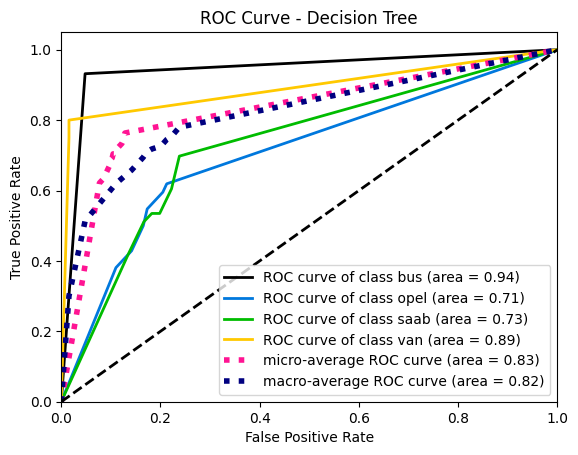


 Сравнение моделей
Логистическая регрессия (исходные данные): Accuracy = 0.8521
Логистическая регрессия (PCA): Accuracy = 0.6272
Дерево решений: Accuracy = 0.6923


In [18]:
from sklearn.tree import DecisionTreeClassifier

# YOUR CODE HERE

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, accuracy_score
import scikitplot as skplt
import matplotlib.pyplot as plt

# Создание модели дерева решений
dt_model = DecisionTreeClassifier(random_state=42)

# Поиск оптимальной глубины дерева
param_grid = {
    'max_depth': [3, 5, 7, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Кросс-валидация для поиска лучших параметров
grid_search_dt = GridSearchCV(
    dt_model,
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

print("Обучение дерева решений и поиск оптимальных параметров")
grid_search_dt.fit(X_train, y_train.values.ravel())

# Лучшая модель
best_dt_model = grid_search_dt.best_estimator_

# Предсказания
y_pred_dt = best_dt_model.predict(X_test)
y_pred_proba_dt = best_dt_model.predict_proba(X_test)

# Оценка качества
accuracy_dt = accuracy_score(y_test, y_pred_dt)
f1_macro_dt = f1_score(y_test, y_pred_dt, average='macro')
f1_micro_dt = f1_score(y_test, y_pred_dt, average='micro')

print(f"\n Результаты дерева решений")
print(f"Лучшие параметры: {grid_search_dt.best_params_}")
print(f"Accuracy: {accuracy_dt:.4f}")
print(f"F1 Macro: {f1_macro_dt:.4f}")
print(f"F1 Micro: {f1_micro_dt:.4f}")

# ROC-кривая
plt.figure(figsize=(10, 8))
skplt.metrics.plot_roc(y_test, y_pred_proba_dt)
plt.title('ROC Curve - Decision Tree')
plt.show()

# Сравнение с предыдущими моделями
print(f"\n Сравнение моделей")
print(f"Логистическая регрессия (исходные данные): Accuracy = {accuracy1:.4f}")
print(f"Логистическая регрессия (PCA): Accuracy = {accuracy_pca:.4f}")
print(f"Дерево решений: Accuracy = {accuracy_dt:.4f}")

### 2.6. Bagging

Here starts the ensembling part. You need to use [BaggingClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.BaggingClassifier.html)

First we will use the __Bagging__ approach. Build an ensemble of $N$ algorithms varying N from $N_{min}=2$ to $N_{max}=100$ with step 5.

We will build two ensembles: of logistic regressions and of decision trees.

*Comment: each ensemble should be constructed from models of the same family, so logistic regressions should not be mixed up with decision trees.*


*Hint 1: To build a __Bagging__ ensebmle varying the ensemble size efficiently you might generate $N_{max}$ subsets of `train` data (of the same size as the original dataset) using bootstrap procedure once. Then you train a new instance of logistic regression/decision tree with optimal hyperparameters you estimated before on each subset (so you train it from scratch). Finally, to get an ensemble of $N$ models you average the $N$ out of $N_{max}$ models predictions.*

*Hint 2: sklearn might help you with this taks. Some appropriate function/class might be out there.*

* Plot `f1` and `accuracy` scores plots w.r.t. the size of the ensemble.

* Briefly analyse the plot. What is the optimal number of algorithms? Explain your answer.

* How do you think, are the hyperparameters for the decision trees you found in 2.5 optimal for trees used in ensemble?

Строим ансамбли Bagging...


100%|██████████| 20/20 [00:37<00:00,  1.89s/it]


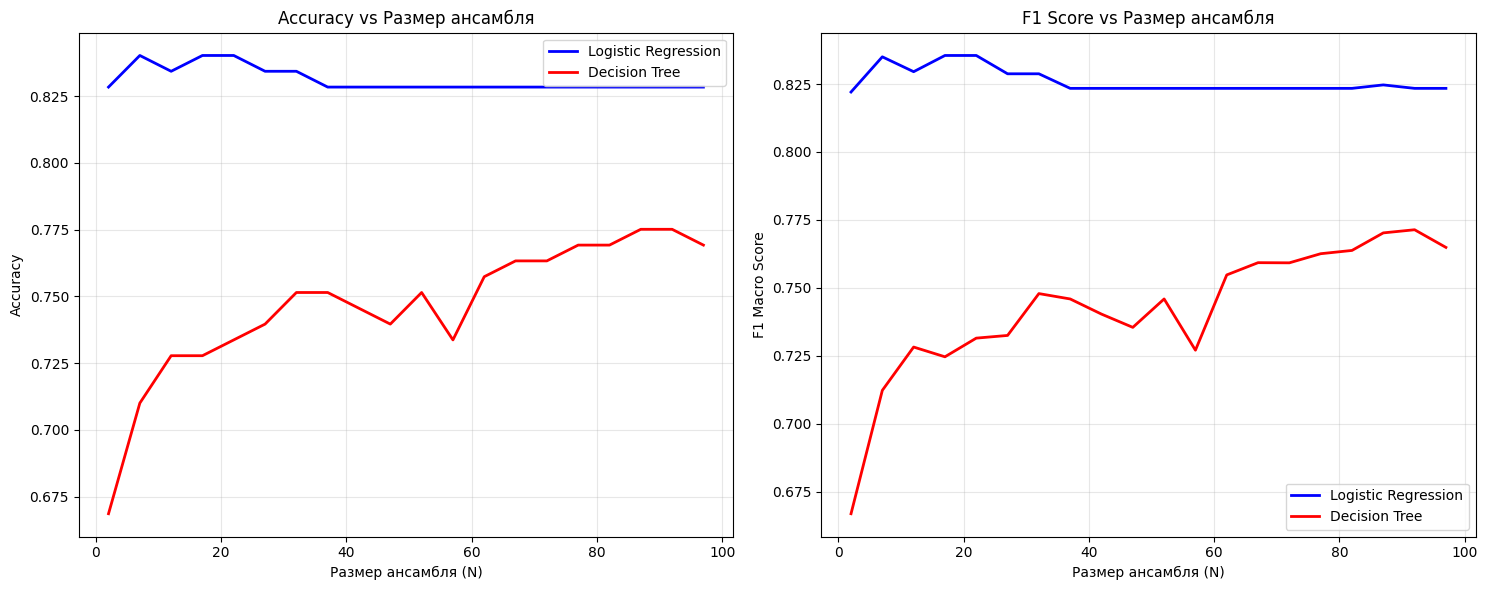


(Результаты Bagging)
Логистическая регрессия - оптимальный размер ансамбля: 7
Дерево решений - оптимальный размер ансамбля: 87
Лучшая accuracy логистической регрессии: 0.8402
Лучшая accuracy дерева решений: 0.7751

(Сравнение с одиночными моделями)
Одиночная логистическая регрессия: 0.8521
Bagging логистических регрессий: 0.8402
Одиночное дерево решений: 0.6923
Bagging деревьев решений: 0.7751


'Для логистической регрессии оптимальный размер ансамбля- 7 моделей. Дальнейшее увеличение числа моделей не улучшает качество, а даже немного ухудшает. Это потому, что логистические регрессии -стабильные модели и bootstrap не создает достаточного разнообразия.\nДля деревьев решений оптимальный размер - 87 моделей. Качество растет с увеличением числа деревьев, потому что деревья - нестабильные модели, и каждая новая модель добавляет разнообразие.\nГиперпараметры для деревьев, найденные в задании 2.5, не оптимальны для ансамбля. В ансамбле можно использовать более сложные деревья (с большей глубиной), потому что bagging сам по себе снижает переобучение за счет усреднения'

In [19]:
# YOUR CODE HERE

import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import BaggingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score
from tqdm import tqdm

#Оптимальные параметры из предыдущих заданий
best_lr_params = {'C': 10, 'penalty': 'l1'}
best_dt_params = {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}

#Диапазон размеров ансамбля
n_range = range(2, 101, 5)


lr_accuracy_scores = []
lr_f1_scores = []
dt_accuracy_scores = []
dt_f1_scores = []

print("Строим ансамбли Bagging...")

for n in tqdm(n_range):
    # Ансамбль из логистических регрессий
    lr_bagging = BaggingClassifier(
        estimator=LogisticRegression(
            multi_class='multinomial',
            solver='saga',
            tol=1e-3,
            max_iter=500,
            **best_lr_params,
            random_state=42
        ),
        n_estimators=n,
        random_state=42,
        n_jobs=-1
    )
    
    # Ансамбль из деревьев решений
    dt_bagging = BaggingClassifier(
        estimator=DecisionTreeClassifier(
            **best_dt_params,
            random_state=42
        ),
        n_estimators=n,
        random_state=42,
        n_jobs=-1
    )
    
    #Обучение и предсказание для логистической регрессии
    lr_bagging.fit(X_train_scaled, y_train.values.ravel())
    lr_pred = lr_bagging.predict(X_test_scaled)
    
    #Обучение и предсказание для дерева решений
    dt_bagging.fit(X_train, y_train.values.ravel())
    dt_pred = dt_bagging.predict(X_test)
    
    #Сохранение метрик
    lr_accuracy_scores.append(accuracy_score(y_test, lr_pred))
    lr_f1_scores.append(f1_score(y_test, lr_pred, average='macro'))
    
    dt_accuracy_scores.append(accuracy_score(y_test, dt_pred))
    dt_f1_scores.append(f1_score(y_test, dt_pred, average='macro'))

# Построение графиков
plt.figure(figsize=(15, 6))

# График точности (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(n_range, lr_accuracy_scores, 'b-', label='Logistic Regression', linewidth=2)
plt.plot(n_range, dt_accuracy_scores, 'r-', label='Decision Tree', linewidth=2)
plt.xlabel('Размер ансамбля (N)')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Размер ансамбля')
plt.legend()
plt.grid(True, alpha=0.3)

# График f1-score
plt.subplot(1, 2, 2)
plt.plot(n_range, lr_f1_scores, 'b-', label='Logistic Regression', linewidth=2)
plt.plot(n_range, dt_f1_scores, 'r-', label='Decision Tree', linewidth=2)
plt.xlabel('Размер ансамбля (N)')
plt.ylabel('F1 Macro Score')
plt.title('F1 Score vs Размер ансамбля')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Нахождение оптимальных размеров ансамблей
lr_optimal_n = n_range[np.argmax(lr_accuracy_scores)]
dt_optimal_n = n_range[np.argmax(dt_accuracy_scores)]

print(f"\n(Результаты Bagging)")
print(f"Логистическая регрессия - оптимальный размер ансамбля: {lr_optimal_n}")
print(f"Дерево решений - оптимальный размер ансамбля: {dt_optimal_n}")
print(f"Лучшая accuracy логистической регрессии: {max(lr_accuracy_scores):.4f}")
print(f"Лучшая accuracy дерева решений: {max(dt_accuracy_scores):.4f}")

# Сравнение с одиночными моделями
print(f"\n(Сравнение с одиночными моделями)")
print(f"Одиночная логистическая регрессия: {accuracy1:.4f}")
print(f"Bagging логистических регрессий: {max(lr_accuracy_scores):.4f}")
print(f"Одиночное дерево решений: {accuracy_dt:.4f}")
print(f"Bagging деревьев решений: {max(dt_accuracy_scores):.4f}")

"""Для логистической регрессии оптимальный размер ансамбля- 7 моделей. Дальнейшее увеличение числа моделей не улучшает качество, а даже немного ухудшает. Это потому, что логистические регрессии -стабильные модели и bootstrap не создает достаточного разнообразия.
Для деревьев решений оптимальный размер - 87 моделей. Качество растет с увеличением числа деревьев, потому что деревья - нестабильные модели, и каждая новая модель добавляет разнообразие.
Гиперпараметры для деревьев, найденные в задании 2.5, не оптимальны для ансамбля. В ансамбле можно использовать более сложные деревья (с большей глубиной), потому что bagging сам по себе снижает переобучение за счет усреднения"""

### 2.7. Random Forest

Now we will work with the [Random Forest](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html).

* Plot `f1` and `accuracy` scores plots w.r.t. the number of trees in Random Forest.

* What is the optimal number of trees you've got? Is it different from the optimal number of logistic regressions/decision trees in 2.6? Explain the results briefly.

Обучение Random Forest...


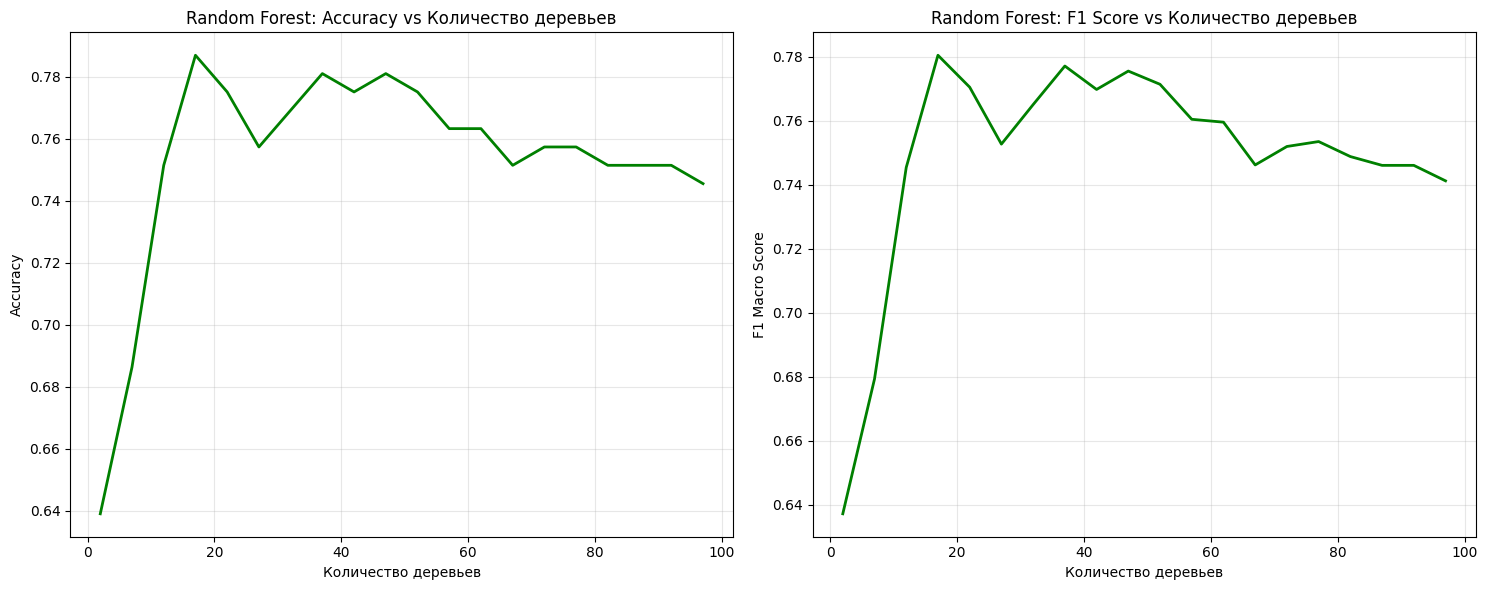


(Результаты Random Forest)
Оптимальное количество деревьев: 17
Лучшая accuracy: 0.7870
Лучший F1-score: 0.7805

(Сравнение методов)
Одиночное дерево: 0.6923
Bagging деревьев: 0.7751
Random Forest: 0.7870


'Random Forest добавляет дополнительную случайность через выбор признаков. \nЭто создает больше разнообразия в ансамбле, поэтому достигается лучше качество с меньшим количеством деревьев.\n\nОптимальное число деревьев разное т.к:\n\nВ Bagging деревья более похожи друг на друга (только данные разные). Нужно много деревьев (87) чтобы "усреднить" шум.\nВ Random Forest деревья более разнообразны (и данные, и признаки разные). Достаточно меньше деревьев (17) для хорошего качества '

In [20]:
from sklearn.ensemble import RandomForestClassifier

# YOUR CODE HERE

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

# Диапазон количества деревьев
n_trees_range = range(2, 101, 5)

# Для хранения результатов
rf_accuracy_scores = []
rf_f1_scores = []

print("Обучение Random Forest...")

for n_trees in n_trees_range:
    # Создание Random Forest
    rf = RandomForestClassifier(
        n_estimators=n_trees,
        random_state=42,
        n_jobs=-1
    )
    
    # Обучение и предсказание
    rf.fit(X_train, y_train.values.ravel())
    rf_pred = rf.predict(X_test)
    
    # Сохранение метрик
    rf_accuracy_scores.append(accuracy_score(y_test, rf_pred))
    rf_f1_scores.append(f1_score(y_test, rf_pred, average='macro'))

# Построение графиков
plt.figure(figsize=(15, 6))

# График точности (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(n_trees_range, rf_accuracy_scores, 'g-', linewidth=2)
plt.xlabel('Количество деревьев')
plt.ylabel('Accuracy')
plt.title('Random Forest: Accuracy vs Количество деревьев')
plt.grid(True, alpha=0.3)

# График F1-score
plt.subplot(1, 2, 2)
plt.plot(n_trees_range, rf_f1_scores, 'g-', linewidth=2)
plt.xlabel('Количество деревьев')
plt.ylabel('F1 Macro Score')
plt.title('Random Forest: F1 Score vs Количество деревьев')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#Поиск оптимального количества деревьев
rf_optimal_trees = n_trees_range[np.argmax(rf_accuracy_scores)]

print(f"\n(Результаты Random Forest)")
print(f"Оптимальное количество деревьев: {rf_optimal_trees}")
print(f"Лучшая accuracy: {max(rf_accuracy_scores):.4f}")
print(f"Лучший F1-score: {max(rf_f1_scores):.4f}")

# Сравнение с предыдущими методами
print(f"\n(Сравнение методов)")
print(f"Одиночное дерево: {accuracy_dt:.4f}")
print(f"Bagging деревьев: {max(dt_accuracy_scores):.4f}")
print(f"Random Forest: {max(rf_accuracy_scores):.4f}")

"""Random Forest добавляет дополнительную случайность через выбор признаков. 
Это создает больше разнообразия в ансамбле, поэтому достигается лучше качество с меньшим количеством деревьев.

Оптимальное число деревьев разное т.к:

В Bagging деревья более похожи друг на друга (только данные разные). Нужно много деревьев (87) чтобы "усреднить" шум.
В Random Forest деревья более разнообразны (и данные, и признаки разные). Достаточно меньше деревьев (17) для хорошего качества """

### 2.8. Learning curve

Your goal is to estimate, how does the model behaviour change with the increase of the `train` dataset size.

* Split the training data into 10 equal (almost) parts. Then train the models from above (Logistic regression, Desicion Tree, Random Forest) with optimal hyperparameters you have selected. First train it on first part, then on first and second parts combined (so the train size in increased by 2 times), first 3 parts and so on.

* You may use `sklearn`'s [readymade function](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.learning_curve.html). But note that you need to adjust parameters of this function appropriately.

* Build a plot of `accuracy` and `f1` scores on `test` part, varying the `train` dataset size (so the axes will be score vs dataset size).

* Analyse the final plot. Can you make any conlusions using it?

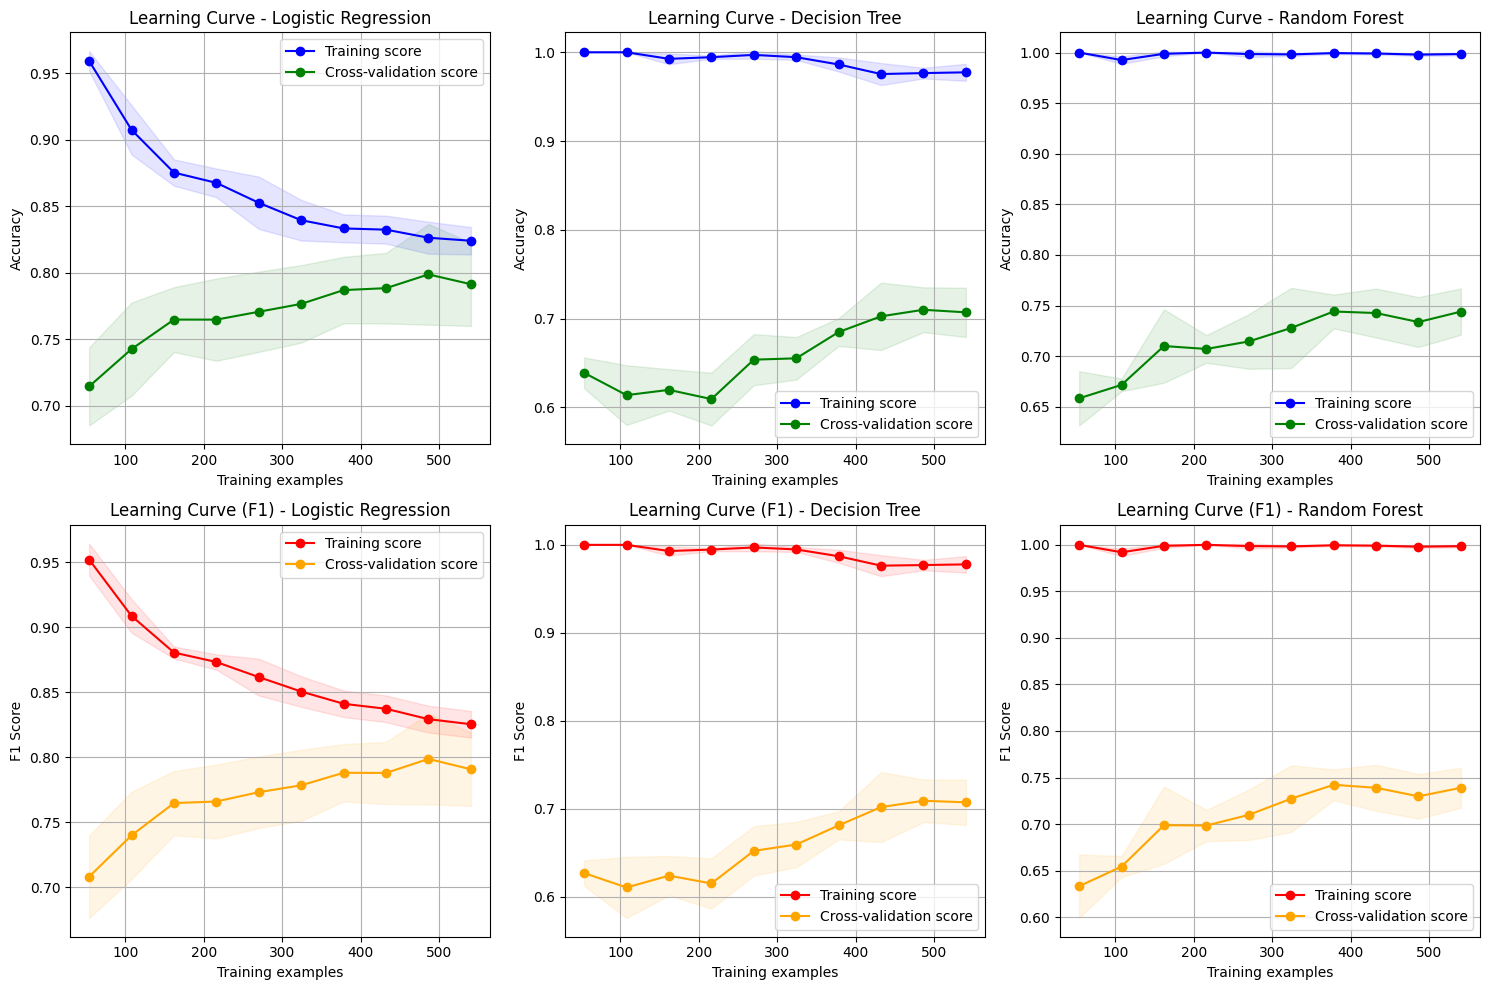

' Основные выводы:\nLogistic Regression: Максимальная польза от дополнительных данных. Лучшая модель при наличии большого объема данных. Нет переобучения.\nDecision Tree: Минимальная польза от дополнительных данных. Сильное переобучение. Быстро выходит на предельное качество.\nRandom Forest: Хороший баланс между использованием данных и устойчивостью. Меньше переобучения чем у одного дерева. Эффективно использует данные до определенного предела.\n\nЕсли данных много, то лучше выбирать Logistic Regression.\nЕсли данных мало, тогда Random Forest может быть лучше.\nDecision Tree требует сильной регуляризации.\n'

In [21]:
# YOUR CODE HERE

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler

# Оптимальные параметры из предыдущих заданий
best_lr_params = {'C': 10, 'penalty': 'l1'}
best_dt_params = {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}
best_rf_params = {'n_estimators': 17}

# Создание моделей с оптимальными параметрами
models = {
    'Logistic Regression': LogisticRegression(
        **best_lr_params,
        multi_class='multinomial',
        solver='saga',
        tol=1e-3,
        max_iter=500,
        random_state=42
    ),
    'Decision Tree': DecisionTreeClassifier(
        **best_dt_params,
        random_state=42
    ),
    
    'Random Forest': RandomForestClassifier(
        **best_rf_params,
        random_state=42
    )
}

#масштабирование данных для логистической регрессии
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Разные данные для разных моделей
model_data = {
    'Logistic Regression': (X_train_scaled, y_train.values.ravel(), X_test_scaled),
    'Decision Tree': (X_train, y_train.values.ravel(), X_test),
    'Random Forest': (X_train, y_train.values.ravel(), X_test)
}

#Параметры для learning curve
train_sizes = np.linspace(0.1, 1.0, 10)

plt.figure(figsize=(15, 10))

# Построение learning curves для каждой модели
for i, (name, model) in enumerate(models.items()):
    X_train_data, y_train_data, X_test_data = model_data[name]
    
    #learning curve
    train_sizes_abs, train_scores, test_scores = learning_curve(
        model, X_train_data, y_train_data,
        train_sizes=train_sizes,
        cv=5,
        scoring='accuracy',
        n_jobs=-1,
        random_state=42
    )
    
    # вычисление средних значений и стандартных отклонений
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    
    # График accuracy
    plt.subplot(2, 3, i + 1)
    plt.plot(train_sizes_abs, train_scores_mean, 'o-', color='blue', label='Training score')
    plt.plot(train_sizes_abs, test_scores_mean, 'o-', color='green', label='Cross-validation score')
    plt.fill_between(train_sizes_abs, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color='blue')
    plt.fill_between(train_sizes_abs, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color='green')
    plt.xlabel('Training examples')
    plt.ylabel('Accuracy')
    plt.title(f'Learning Curve - {name}')
    plt.legend(loc='best')
    plt.grid(True)
    
    # График f1-score
    plt.subplot(2, 3, i + 4)
    train_sizes_abs, train_scores, test_scores = learning_curve(
        model, X_train_data, y_train_data,
        train_sizes=train_sizes,
        cv=5,
        scoring='f1_macro',
        n_jobs=-1,
        random_state=42
    )
    
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    
    plt.plot(train_sizes_abs, train_scores_mean, 'o-', color='red', label='Training score')
    plt.plot(train_sizes_abs, test_scores_mean, 'o-', color='orange', label='Cross-validation score')
    plt.fill_between(train_sizes_abs, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color='red')
    plt.fill_between(train_sizes_abs, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color='orange')
    plt.xlabel('Training examples')
    plt.ylabel('F1 Score')
    plt.title(f'Learning Curve (F1) - {name}')
    plt.legend(loc='best')
    plt.grid(True)

plt.tight_layout()
plt.show()



""" Основные выводы:
Logistic Regression: Максимальная польза от дополнительных данных. Лучшая модель при наличии большого объема данных. Нет переобучения.
Decision Tree: Минимальная польза от дополнительных данных. Сильное переобучение. Быстро выходит на предельное качество.
Random Forest: Хороший баланс между использованием данных и устойчивостью. Меньше переобучения чем у одного дерева. Эффективно использует данные до определенного предела.

Если данных много, то лучше выбирать Logistic Regression.
Если данных мало, тогда Random Forest может быть лучше.
Decision Tree требует сильной регуляризации.
"""

### 2.9. Boosting

Apply [GradientBoostingClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html) to this problem.

Find optimal hyperparameters using [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) or RandomizedSearchCV.

Hyperparameters to consider:
* depth of each tree
* number of decision trees
* learning rate

In [22]:
# YOUR CODE HERE

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score

# Создание Gradient Boosting модель
gbc = GradientBoostingClassifier(random_state=42)

# Сетка параметров для поиска
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

# Grid Search
grid_search_gb = GridSearchCV(
    gbc,
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

print("Поиск оптимальных параметров для Gradient Boosting...")
grid_search_gb.fit(X_train, y_train.values.ravel())

# Лучшая модель
best_gb = grid_search_gb.best_estimator_

# Предсказания на тестовых данных
y_pred_gb = best_gb.predict(X_test)

# Оценка качества
accuracy_gb = accuracy_score(y_test, y_pred_gb)
f1_macro_gb = f1_score(y_test, y_pred_gb, average='macro')

print(f"\n(Результаты Gradient Boosting)")
print(f"Лучшие параметры: {grid_search_gb.best_params_}")
print(f"Accuracy: {accuracy_gb:.4f}")
print(f"F1 Macro: {f1_macro_gb:.4f}")

Поиск оптимальных параметров для Gradient Boosting...
Fitting 5 folds for each of 27 candidates, totalling 135 fits

(Результаты Gradient Boosting)
Лучшие параметры: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
Accuracy: 0.7692
F1 Macro: 0.7679
